# 02d — Xem xét box "reddish" của AgRobTomato (`review_required.csv`)

**Bối cảnh:** `01_build_tomato_ripeness_v1.ipynb` chủ động **không** tự remap class gốc `"reddish"` của AgRobTomato — vì không rõ nó tương ứng `fruit_turning` hay `fruit_ripe` chỉ dựa vào tên. 116 ảnh có box này bị loại khỏi label, ghi vào `manifests/review_required.csv`, đúng nguyên tắc "không remap chỉ dựa vào tên" của dự án.

**Mục tiêu notebook này:** xem trực tiếp các box "reddish" (vẽ trên ảnh gốc) + tính màu trung bình (Hue) bên trong mỗi box, để quyết định dựa trên bằng chứng thay vì đoán:
- Nếu các box "reddish" tạo thành 2 cụm màu rõ rệt (ngả cam vs ngả đỏ đậm) → có thể tách theo ngưỡng Hue thành `fruit_turning` / `fruit_ripe`.
- Nếu tất cả gần giống nhau → có thể gộp chung vào 1 class, quyết định dựa trên nhìn thực tế màu quả.

Notebook này **không sửa dataset** — chỉ sinh `reddish_class_decision.csv` (đề xuất class cho từng box, kèm bằng chứng) để áp dụng vào lần build tiếp theo, giống cách đã làm với `review_candidates_negative.csv` ở nhánh bệnh lá.

## Trước khi chạy
1. **Add Input** → output đã Save Version của `00_data_acquisition_ripeness.ipynb` (chứa `raw/agrob_tomato/` — ảnh gốc + XML gốc, cần để đọc đúng tọa độ box "reddish").
2. **Add Input** thêm → output đã Save Version của `01_build_tomato_ripeness_v1.ipynb` (chứa `manifests/review_required.csv`).
3. Không cần GPU. Internet: OFF được (không tải gì).

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

RAW_AGROB_DIR = None
for p in Path("/kaggle/input").rglob("agrob_tomato"):
    if p.is_dir() and (p / "Dataset-Greenhouse_Tomato_AgRob").exists():
        RAW_AGROB_DIR = p / "Dataset-Greenhouse_Tomato_AgRob"
        break
    # Cấu trúc có thể lồng khác nhau tùy Kaggle -> kiểm tra thêm bằng cách tìm Annotations bên trong.
    ann_hits = list(p.rglob("Annotations"))
    if ann_hits:
        RAW_AGROB_DIR = ann_hits[0].parent
        break

review_csv_hits = list(Path("/kaggle/input").rglob("review_required.csv"))

if RAW_AGROB_DIR is None:
    print("Các thư mục cấp 1 trong /kaggle/input:")
    for p in sorted(Path("/kaggle/input").glob("*")):
        print(" -", p)
    raise FileNotFoundError(
        "Không tìm thấy raw/agrob_tomato trong /kaggle/input. Kiểm tra đã Add Input output đã Save "
        "Version của 00_data_acquisition_ripeness.ipynb chưa."
    )
if not review_csv_hits:
    raise FileNotFoundError(
        "Không tìm thấy review_required.csv trong /kaggle/input. Kiểm tra đã Add Input output đã "
        "Save Version của 01_build_tomato_ripeness_v1.ipynb chưa."
    )

REVIEW_CSV = review_csv_hits[0]
ANNOTATIONS_DIR = RAW_AGROB_DIR / "Annotations"
IMAGES_DIR = RAW_AGROB_DIR / "JPEGImages"

print("RAW_AGROB_DIR:", RAW_AGROB_DIR)
print("REVIEW_CSV   :", REVIEW_CSV)
print("Annotations tồn tại:", ANNOTATIONS_DIR.exists(), "| JPEGImages tồn tại:", IMAGES_DIR.exists())

review_df = pd.read_csv(REVIEW_CSV)
review_df = review_df[review_df["source"] == "agrob_tomato"]
print(f"\nSố ảnh có box 'reddish' cần review: {len(review_df)}")
print(review_df.head())

RAW_AGROB_DIR: /kaggle/input/notebooks/sonlest/00-data-acquisition-ripeness/ai/datasets/raw/agrob_tomato/Dataset-Greenhouse_Tomato_AgRob
REVIEW_CSV   : /kaggle/input/notebooks/sonlest/01-build-tomato-ripeness-v1/ai/datasets/manifests/review_required.csv
Annotations tồn tại: True | JPEGImages tồn tại: True

Số ảnh có box 'reddish' cần review: 116
         source                                image  n_review_boxes
0  agrob_tomato  tomate_barroselas_20200806_0130.jpg               1
1  agrob_tomato  tomate_barroselas_20200806_0215.jpg               2
2  agrob_tomato  tomate_barroselas_20200806_0014.jpg               1
3  agrob_tomato  tomate_barroselas_20200806_0216.jpg               1
4  agrob_tomato  tomate_barroselas_20200806_0034.jpg               1


### Bước 1 — Bóc tọa độ box "reddish" từ XML gốc + tính màu trung bình
Không đoán màu — tính Hue trung bình thật của từng box bằng cách đọc trực tiếp pixel ảnh gốc.

In [2]:
def parse_voc_boxes(xml_path):
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        cname = obj.find("name").text.strip().lower()
        bnd = obj.find("bndbox")
        xmin, ymin = float(bnd.find("xmin").text), float(bnd.find("ymin").text)
        xmax, ymax = float(bnd.find("xmax").text), float(bnd.find("ymax").text)
        boxes.append((cname, xmin, ymin, xmax, ymax))
    return boxes


def mean_hue_in_box(img, box):
    xmin, ymin, xmax, ymax = [int(round(v)) for v in box]
    xmin, ymin = max(0, xmin), max(0, ymin)
    xmax, ymax = min(img.width, xmax), min(img.height, ymax)
    if xmax <= xmin or ymax <= ymin:
        return None, None
    crop = img.crop((xmin, ymin, xmax, ymax)).convert("HSV")
    arr = np.asarray(crop).reshape(-1, 3)
    h_mean = float(np.mean(arr[:, 0])) * 360.0 / 255.0  # PIL HSV: H in 0..255 -> quy về 0..360 độ
    s_mean = float(np.mean(arr[:, 1])) / 255.0
    return h_mean, s_mean


records = []
for _, row in review_df.iterrows():
    stem = Path(row["image"]).stem
    xml_path = ANNOTATIONS_DIR / f"{stem}.xml"
    img_path = IMAGES_DIR / row["image"]
    if not xml_path.exists() or not img_path.exists():
        print(f"[bỏ qua] thiếu file cho {row['image']}")
        continue
    boxes = parse_voc_boxes(xml_path)
    with Image.open(img_path) as img:
        for i, (cname, *box) in enumerate(boxes):
            if cname != "reddish":
                continue
            h_mean, s_mean = mean_hue_in_box(img, box)
            if h_mean is None:
                continue
            records.append({
                "image": row["image"], "box_index": i,
                "xmin": box[0], "ymin": box[1], "xmax": box[2], "ymax": box[3],
                "hue_deg": round(h_mean, 1), "saturation": round(s_mean, 3),
            })

reddish_df = pd.DataFrame(records)
print(f"Tổng số box 'reddish' đọc được: {len(reddish_df)} (so với {review_df['n_review_boxes'].sum()} ghi trong CSV)")
print(reddish_df["hue_deg"].describe())

Tổng số box 'reddish' đọc được: 184 (so với 184 ghi trong CSV)
count    184.000000
mean      57.356522
std       14.763015
min       33.000000
25%       48.250000
50%       54.150000
75%       61.000000
max      118.300000
Name: hue_deg, dtype: float64


### Bước 2 — So sánh với 2 class đã biết chắc chắn (`riped`, `breaking`)
Thay vì đoán ngưỡng Hue mù quáng, lấy Hue trung bình của các box `riped` (→ `fruit_ripe`) và `breaking` (→ `fruit_turning`) đã xác nhận đúng từ trước làm điểm neo — cùng nguồn ảnh, cùng camera/ánh sáng nên so sánh công bằng. Lấy mẫu ngẫu nhiên 150 box/class cho nhanh (dataset có hàng nghìn box).

In [3]:
import random

random.seed(42)

REFERENCE_CLASSES = {"riped": "fruit_ripe", "breaking": "fruit_turning", "unriped": "fruit_green_unripe"}
all_xml = sorted(ANNOTATIONS_DIR.glob("*.xml"))

ref_candidates = {cname: [] for cname in REFERENCE_CLASSES}
for xml_path in all_xml:
    boxes = parse_voc_boxes(xml_path)
    img_name = xml_path.stem + ".jpg"
    for i, (cname, *box) in enumerate(boxes):
        if cname in REFERENCE_CLASSES:
            ref_candidates[cname].append((img_name, i, box))

ref_records = []
for cname, items in ref_candidates.items():
    sample = random.sample(items, min(150, len(items)))
    img_cache = {}
    for img_name, box_idx, box in sample:
        if img_name not in img_cache:
            img_cache[img_name] = Image.open(IMAGES_DIR / img_name)
        h_mean, s_mean = mean_hue_in_box(img_cache[img_name], box)
        if h_mean is not None:
            ref_records.append({"raw_class": cname, "target_class": REFERENCE_CLASSES[cname],
                                 "hue_deg": h_mean, "saturation": s_mean})
    for im in img_cache.values():
        im.close()

ref_df = pd.DataFrame(ref_records)
print(ref_df.groupby("raw_class")["hue_deg"].describe()[["count", "mean", "std", "min", "max"]])

           count       mean        std        min         max
raw_class                                                    
breaking   150.0  64.049594  16.832280  39.542484  176.349990
riped       30.0  54.937198  25.124038  25.232970  136.068207
unriped    150.0  89.642782  17.114637  61.626891  155.264277


### Bước 3 — Biểu đồ so sánh phân bố Hue + đề xuất ngưỡng

Hue trung bình tham chiếu: unriped(xanh)=89.6°  breaking(chuyển màu)=64.0°  riped(chín)=54.9°


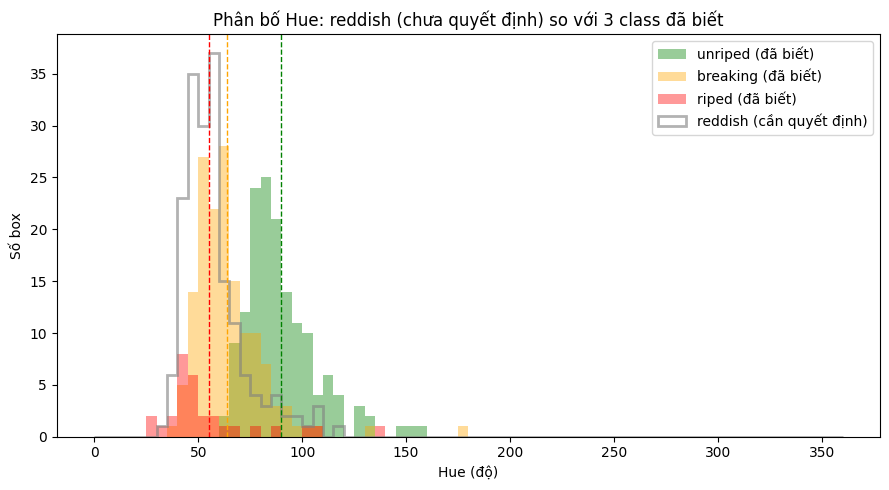


Phân loại đề xuất theo khoảng cách gần nhất tới 2 tâm màu (breaking vs riped):
nearest_class
fruit_ripe       130
fruit_turning     54
Name: count, dtype: int64


In [4]:
unriped_mean = ref_df[ref_df.raw_class == "unriped"]["hue_deg"].mean()
breaking_mean = ref_df[ref_df.raw_class == "breaking"]["hue_deg"].mean()
riped_mean = ref_df[ref_df.raw_class == "riped"]["hue_deg"].mean()

print(f"Hue trung bình tham chiếu: unriped(xanh)={unriped_mean:.1f}°  "
      f"breaking(chuyển màu)={breaking_mean:.1f}°  riped(chín)={riped_mean:.1f}°")


def circular_dist(a, b):
    d = abs(a - b) % 360
    return min(d, 360 - d)


def decide_class(h):
    d_turning = circular_dist(h, breaking_mean)
    d_ripe = circular_dist(h, riped_mean)
    return "fruit_turning" if d_turning <= d_ripe else "fruit_ripe"


reddish_df["nearest_class"] = reddish_df["hue_deg"].apply(decide_class)

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 360, 73)
for cname, color in [("unriped", "green"), ("breaking", "orange"), ("riped", "red")]:
    ax.hist(ref_df[ref_df.raw_class == cname]["hue_deg"], bins=bins, alpha=0.4, label=f"{cname} (đã biết)", color=color)
ax.hist(reddish_df["hue_deg"], bins=bins, alpha=0.6, label="reddish (cần quyết định)", color="gray", histtype="step", linewidth=2)
for m, c, l in [(unriped_mean, "green", "unriped mean"), (breaking_mean, "orange", "breaking mean"),
                (riped_mean, "red", "riped mean")]:
    ax.axvline(m, color=c, linestyle="--", linewidth=1)
ax.set_xlabel("Hue (độ)")
ax.set_ylabel("Số box")
ax.set_title("Phân bố Hue: reddish (chưa quyết định) so với 3 class đã biết")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/reddish_hue_histogram.png", dpi=100, bbox_inches="tight")
plt.show()
plt.close()

print("\nPhân loại đề xuất theo khoảng cách gần nhất tới 2 tâm màu (breaking vs riped):")
print(reddish_df["nearest_class"].value_counts())

### Bước 4 — Xác nhận trực quan mẫu ngẫu nhiên (bắt buộc trước khi tin tưởng ngưỡng)
Vẽ box "reddish" (màu tím) lên ảnh thật kèm nhãn đề xuất, để xác nhận bằng mắt trước khi áp dụng.

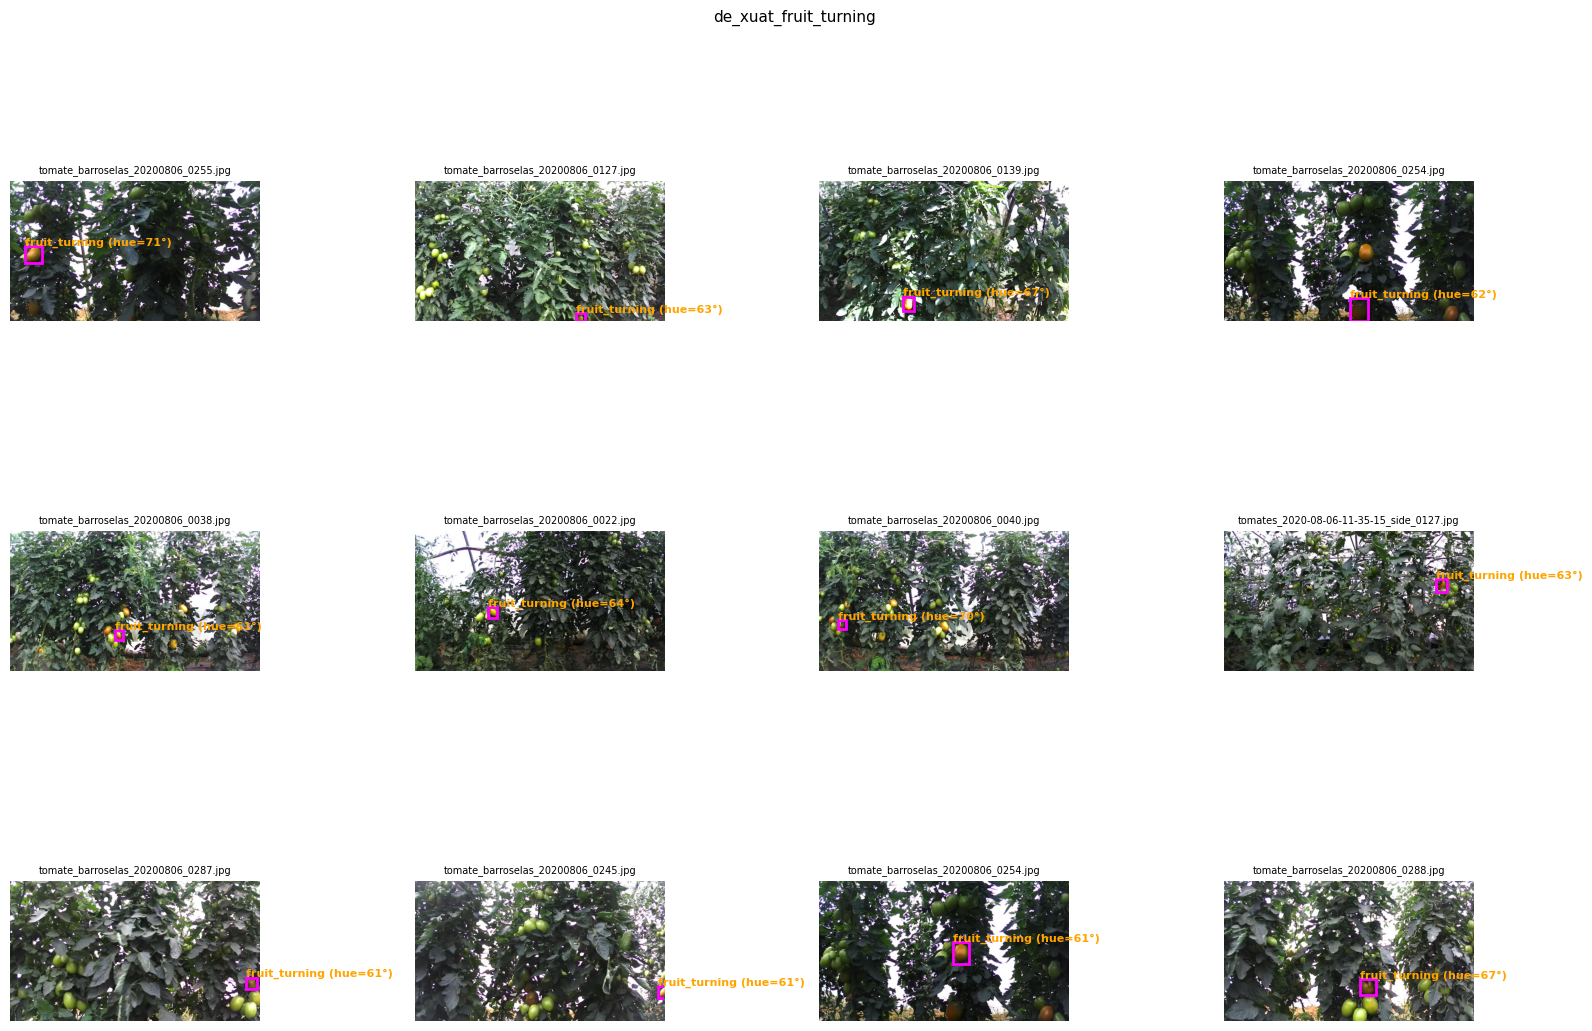

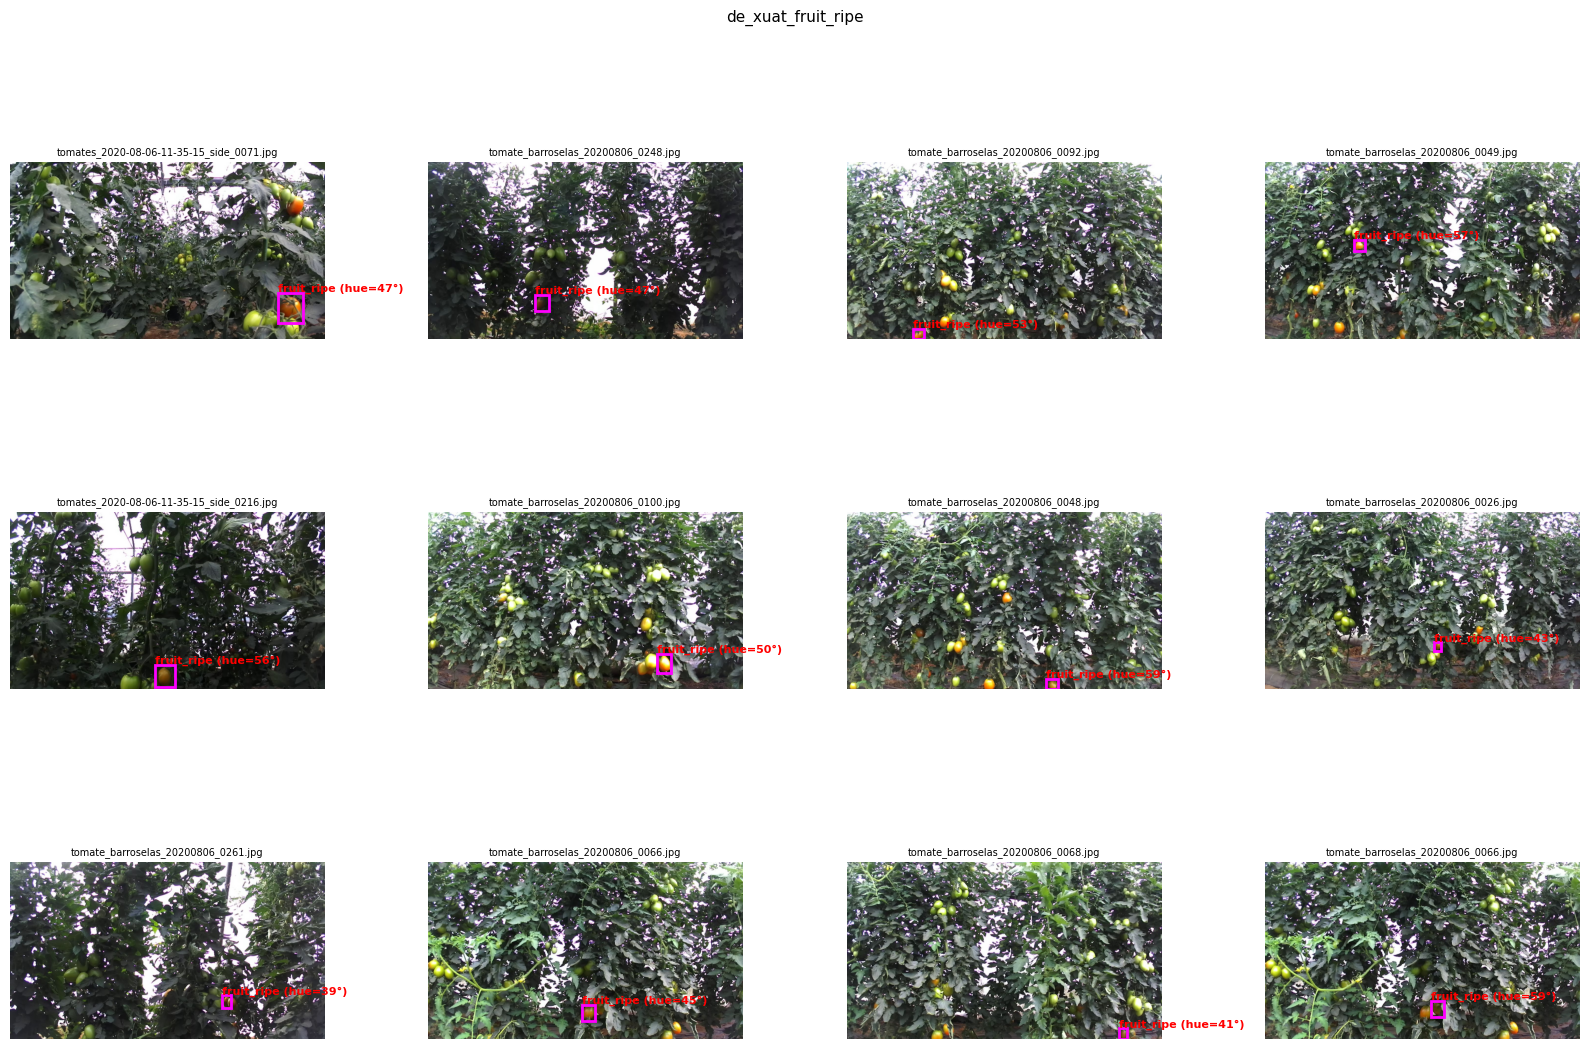

In [5]:
def show_reddish_samples(df, n=12, cols=4, title=""):
    sample = df.sample(min(n, len(df)), random_state=42)
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]
    color_map = {"fruit_turning": "orange", "fruit_ripe": "red"}
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(IMAGES_DIR / row["image"])
        ax.imshow(img)
        rect = patches.Rectangle((row["xmin"], row["ymin"]), row["xmax"] - row["xmin"], row["ymax"] - row["ymin"],
                                  linewidth=2, edgecolor="magenta", facecolor="none")
        ax.add_patch(rect)
        label = f"{row['nearest_class']} (hue={row['hue_deg']:.0f}°)"
        ax.text(row["xmin"], max(row["ymin"] - 8, 0), label, color=color_map.get(row["nearest_class"], "magenta"),
                fontsize=8, weight="bold")
        ax.set_title(row["image"], fontsize=7)
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/reddish_samples_{title}.png", dpi=90, bbox_inches="tight")
    plt.show()
    plt.close(fig)


show_reddish_samples(reddish_df[reddish_df.nearest_class == "fruit_turning"], title="de_xuat_fruit_turning")
show_reddish_samples(reddish_df[reddish_df.nearest_class == "fruit_ripe"], title="de_xuat_fruit_ripe")

In [6]:
reddish_df.to_csv("/kaggle/working/reddish_class_decision.csv", index=False)
print("Đã lưu: /kaggle/working/reddish_class_decision.csv")
print(f"\nTóm tắt: {len(reddish_df)} box 'reddish' -> "
      f"{(reddish_df.nearest_class == 'fruit_turning').sum()} đề xuất fruit_turning, "
      f"{(reddish_df.nearest_class == 'fruit_ripe').sum()} đề xuất fruit_ripe.")

Đã lưu: /kaggle/working/reddish_class_decision.csv

Tóm tắt: 184 box 'reddish' -> 54 đề xuất fruit_turning, 130 đề xuất fruit_ripe.


## Kết quả & cách dùng
- `reddish_class_decision.csv`: mỗi dòng là 1 box "reddish" + tọa độ + Hue đo được + `nearest_class` đề xuất (dựa trên khoảng cách Hue tới tâm màu `breaking`/`riped` đã biết, không phải đoán).
- **Bắt buộc xem ảnh ở Bước 4** trước khi tin: nếu box nào bị gắn nhãn rõ ràng sai màu (vd rất đỏ nhưng lại đề xuất `fruit_turning`), đó là dấu hiệu box đó nằm gần ranh giới hoặc ảnh có ánh sáng bất thường — nên loại riêng các trường hợp này thay vì tin toàn bộ.
- Nếu kết quả nhìn hợp lý: đưa `reddish_class_decision.csv` này làm input cho lần build tiếp theo của `01_build_tomato_ripeness_v1.ipynb`, sửa `CLASS_MAPPING["agrob_tomato"]["name_map"]["reddish"]` từ `REVIEW_REQUIRED` sang tra cứu theo từng box trong CSV này (giống cơ chế `exclude_negative_origfilenames` đã làm ở nhánh bệnh lá, nhưng ở đây là gán class thay vì loại ảnh).